# H₂: viscosity and density versus pressure and temperature

**Objective.** Use only public `thermoml-io` APIs to collect every eligible
H₂-containing dataset for viscosity and density, rank publications by the
number of returned property-condition pairs, retain the top ten publications,
plot the selected data, and export one provenance-complete CSV for each query.

**Success criteria.** No archive URL or checksum is supplied by this notebook;
component inclusion is semantic; pressure/temperature must be reported
independent variables; all citation and experimental metadata remain attached;
and publication truncation occurs only after the complete matching scan.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

from thermoml_io import (
    catalog_thermoml_archive,
    fetch_thermoml_archive,
    get_archive_source,
    query_thermoml_archive,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
LOCAL_CACHE = PROJECT_ROOT / "notebooks/local-only/archive"
LOCAL_EXPORT = PROJECT_ROOT / "notebooks/local-only/exports"
H2_INCHIKEY = "UFHFLCQGNIYNRP-UHFFFAOYSA-N"
PUBLICATION_LIMIT = 10

source = get_archive_source()
archive_path = fetch_thermoml_archive(cache_dir=LOCAL_CACHE)
display(
    pd.DataFrame(
        {
            "field": ["snapshot", "snapshot date", "NIST record", "SHA-256"],
            "value": [
                source.filename,
                source.snapshot_date,
                source.record_version,
                source.sha256,
            ],
        }
    )
)

,field,value
0,snapshot,ThermoML.v2020-09-30.tgz
1,snapshot date,2020-09-30
2,NIST record,1.2.6
3,SHA-256,231161b5e443dc1ae0e5da8429d86a88474cb722016e5b...


## Complete-snapshot catalog

The catalog is generated from all decodable XML members. It supplies exact
category, property, and independent-variable names instead of relying on a
manually maintained vocabulary. `density` deliberately matches both mass and
amount density when both are present.

In [2]:
catalog = catalog_thermoml_archive(archive_path)

transport_properties = pd.DataFrame(
    [
        {"property": item.label, "relationship count": item.count}
        for item in catalog.properties("transport")
    ]
)
volumetric_properties = pd.DataFrame(
    [
        {"property": item.label, "relationship count": item.count}
        for item in catalog.properties("volumetric")
    ]
)
available_conditions = pd.DataFrame(
    [
        {
            "category": category,
            "property query": property_query,
            "condition": item.label,
            "relationship count": item.count,
        }
        for category, property_query in (
            ("transport", "viscosity"),
            ("volumetric", "density"),
        )
        for item in catalog.independent_variables(category, property_query)
    ]
)

display(
    pd.DataFrame(
        {
            "metric": [
                "XML members",
                "decoded members",
                "catalog combinations",
                "official JSON recoveries",
                "explicit failures",
            ],
            "count": [
                catalog.xml_document_count,
                catalog.parsed_document_count,
                len(catalog.entries),
                len(catalog.recoveries),
                len(catalog.failures),
            ],
        }
    )
)
display(transport_properties)
display(volumetric_properties)
display(available_conditions.head(20))

,metric,count
0,XML members,11923
1,decoded members,11923
2,catalog combinations,696
3,official JSON recoveries,2
4,explicit failures,0


,property,relationship count
0,"Viscosity, Pa*s",570728
1,"Electrical conductivity, S/m",155966
2,"Thermal conductivity, W/m/K",51382
3,"Molar conductivity, S*m2/mol",29491
4,"Kinematic viscosity, m2/s",13916
5,"Binary diffusion coefficient, m2/s",12407
6,"Thermal diffusivity, m2/s",7033
7,"Tracer diffusion coefficient, m2/s",681
8,"Self diffusion coefficient, m2/s",499


,property,relationship count
0,"Mass density, kg/m3",1892688
1,"Excess molar volume, m3/mol",32181
2,"Isobaric coefficient of expansion, 1/K",9651
3,"Apparent molar volume, m3/mol",9641
4,"Specific volume, m3/kg",9163
5,"Molar volume, m3/mol",8448
6,"Amount density, mol/m3",7954
7,"Isothermal compressibility, 1/kPa",3484
8,Compressibility factor,1848
9,"Partial molar volume, m3/mol",1002


,category,property query,condition,relationship count
0,transport,viscosity,"Temperature, K",254847
1,transport,viscosity,Mole fraction,141318
2,transport,viscosity,"Molality, mol/kg",76687
3,transport,viscosity,"Solvent: Molality, mol/kg",37696
4,transport,viscosity,"Pressure, kPa",33030
5,transport,viscosity,Mass fraction,17033
6,transport,viscosity,Solvent: Mass fraction,8827
7,transport,viscosity,"Amount concentration (molarity), mol/dm3",8234
8,transport,viscosity,Solvent: Mole fraction,3659
9,transport,viscosity,"Solvent: Amount concentration (molarity), mol/dm3",663


## Component and publication policy

`component_match="contains"` requires H₂ in every returned system and permits
other components. Alternatives exposed by the same API are:

- `exact`: only the exact supplied system;
- `within`: only subsets of an allowed component pool, with
  `required_components` defining the mandatory subset.

The stable InChIKey is also used as a byte prefilter for speed. Semantic
identity matching after XML parsing remains authoritative. The friendly name
is resolved once through the component index already collected by the
complete-snapshot catalog; all four queries reuse the resulting identity.

In [3]:
component_index = catalog.component_index
h2 = component_index.resolve("hydrogen")
display(
    pd.DataFrame(
        {
            "field": ["preferred name", "formula", "InChIKey"],
            "value": [
                h2.preferred_name,
                " | ".join(h2.formulas),
                " | ".join(h2.standard_inchi_keys),
            ],
        }
    )
)

query_specs = {
    "viscosity_vs_pressure": ("transport", "viscosity", "pressure"),
    "viscosity_vs_temperature": ("transport", "viscosity", "temperature"),
    "density_vs_pressure": ("volumetric", "density", "pressure"),
    "density_vs_temperature": ("volumetric", "density", "temperature"),
}

results = {
    label: query_thermoml_archive(
        archive_path,
        components=h2,
        component_index=component_index,
        component_match="contains",
        data_category=category,
        property_name=property_query,
        independent_variable=condition,
        publication_limit=PUBLICATION_LIMIT,
        serialized_prefilters=(H2_INCHIKEY,),
    )
    for label, (category, property_query, condition) in query_specs.items()
}

summary = pd.DataFrame(
    [
        {
            "query": label,
            "available publications": result.available_publication_count,
            "selected publications": len(result.publications),
            "matching datasets before publication limit": result.matched_dataset_count,
            "returned relationships": len(result.table.rows),
            "official JSON recoveries after prefilter": len(result.recoveries),
            "parse failures after prefilter": len(result.failures),
        }
        for label, result in results.items()
    ]
)
display(summary)

,field,value
0,preferred name,hydrogen
1,formula,H2
2,InChIKey,UFHFLCQGNIYNRP-UHFFFAOYSA-N


,query,available publications,selected publications,matching datasets before publication limit,returned relationships,official JSON recoveries after prefilter,parse failures after prefilter
0,viscosity_vs_pressure,2,2,2,37,0,0
1,viscosity_vs_temperature,3,3,4,61,0,0
2,density_vs_pressure,9,9,24,1182,0,0
3,density_vs_temperature,6,6,19,1127,0,0


## Publication rankings and representative metadata

The ranking metric is the number of returned property-condition rows. Every
row still contains DOI, title, authors, journal, year, dataset provenance,
system, phase, method, constraints, samples, and uncertainty metadata.

In [4]:
publication_rankings = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "query": label,
                    "rank": rank,
                    "authors and year": item.authors_year,
                    "doi": item.doi,
                    "year": item.year,
                    "relationships": item.relationship_count,
                    "title": item.title,
                }
                for rank, item in enumerate(result.publications, start=1)
            ]
        )
        for label, result in results.items()
    ],
    ignore_index=True,
)
display(publication_rankings)

metadata_preview = (
    results["density_vs_pressure"]
    .table.to_pandas()[
        [
            "doi",
            "publication_year",
            "citation_title",
            "citation_authors_year",
            "citation_apa",
            "citation_bibtex",
            "system_type",
            "components",
            "property_name",
            "value",
            "independent_variable_name",
            "independent_variable_value",
            "constraints_json",
            "uncertainties_json",
        ]
    ]
    .head(8)
)
display(metadata_preview)

,query,rank,authors and year,doi,year,relationships,title
0,viscosity_vs_pressure,1,Sakoda et al. (2015),10.1016/j.jct.2015.04.028,2015,20,Viscosity measurements of hydrogen at high tem...
1,viscosity_vs_pressure,2,Yusibani et al. (2011),10.1007/s10765-011-0999-6,2011,17,A Capillary Tube Viscometer Designed for Measu...
2,viscosity_vs_temperature,1,Maltsev et al. (2004),10.1021/je0342419,2004,24,"Viscosity of H2-CO2 Mixtures at (500, 800, and..."
3,viscosity_vs_temperature,2,Sakoda et al. (2015),10.1016/j.jct.2015.04.028,2015,20,Viscosity measurements of hydrogen at high tem...
4,viscosity_vs_temperature,3,Yusibani et al. (2011),10.1007/s10765-011-0999-6,2011,17,A Capillary Tube Viscometer Designed for Measu...
5,density_vs_pressure,1,Hernandez-Gomez et al. (2017),10.1021/acs.jced.7b00694,2017,399,"Accurate Experimental (p, , T) Data for the I..."
6,density_vs_pressure,2,Hernandez-Gomez et al. (2018),10.1021/acs.jced.7b01125,2018,391,"Accurate Experimental (p, rho, and T) Data for..."
7,density_vs_pressure,3,Cipollina et al. (2007),10.1021/je700307r,2007,184,Experimental P-T-G Measurements of Supercritic...
8,density_vs_pressure,4,Sakoda et al. (2012),10.1007/s10765-012-1168-2,2012,104,Burnett PVT Measurements of Hydrogen and the D...
9,density_vs_pressure,5,Cheng et al. (2019),10.1021/acs.jced.8b01206,2019,32,Density Data of Two (H2 + CO2) Mixtures and a ...


,doi,publication_year,citation_title,citation_authors_year,citation_apa,citation_bibtex,system_type,components,property_name,value,independent_variable_name,independent_variable_value,constraints_json,uncertainties_json
0,10.1021/acs.jced.7b00694,2017,"Accurate Experimental (p, , T) Data for the I...",Hernandez-Gomez et al. (2017),"Hernandez-Gomez, R., Tuma, D., Gomez-Hernandez...","@article{hernandezgomez2017_0d0f55ed,\n autho...",binary,nitrogen | hydrogen,"Mass density, kg/m3",266.493,"Pressure, kPa",19977,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
1,10.1021/acs.jced.7b00694,2017,"Accurate Experimental (p, , T) Data for the I...",Hernandez-Gomez et al. (2017),"Hernandez-Gomez, R., Tuma, D., Gomez-Hernandez...","@article{hernandezgomez2017_0d0f55ed,\n autho...",binary,nitrogen | hydrogen,"Mass density, kg/m3",255.783,"Pressure, kPa",19018,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
2,10.1021/acs.jced.7b00694,2017,"Accurate Experimental (p, , T) Data for the I...",Hernandez-Gomez et al. (2017),"Hernandez-Gomez, R., Tuma, D., Gomez-Hernandez...","@article{hernandezgomez2017_0d0f55ed,\n autho...",binary,nitrogen | hydrogen,"Mass density, kg/m3",244.268,"Pressure, kPa",18019,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
3,10.1021/acs.jced.7b00694,2017,"Accurate Experimental (p, , T) Data for the I...",Hernandez-Gomez et al. (2017),"Hernandez-Gomez, R., Tuma, D., Gomez-Hernandez...","@article{hernandezgomez2017_0d0f55ed,\n autho...",binary,nitrogen | hydrogen,"Mass density, kg/m3",232.236,"Pressure, kPa",17007,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
4,10.1021/acs.jced.7b00694,2017,"Accurate Experimental (p, , T) Data for the I...",Hernandez-Gomez et al. (2017),"Hernandez-Gomez, R., Tuma, D., Gomez-Hernandez...","@article{hernandezgomez2017_0d0f55ed,\n autho...",binary,nitrogen | hydrogen,"Mass density, kg/m3",220.048,"Pressure, kPa",16011,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
5,10.1021/acs.jced.7b00694,2017,"Accurate Experimental (p, , T) Data for the I...",Hernandez-Gomez et al. (2017),"Hernandez-Gomez, R., Tuma, D., Gomez-Hernandez...","@article{hernandezgomez2017_0d0f55ed,\n autho...",binary,nitrogen | hydrogen,"Mass density, kg/m3",207.511,"Pressure, kPa",15014,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
6,10.1021/acs.jced.7b00694,2017,"Accurate Experimental (p, , T) Data for the I...",Hernandez-Gomez et al. (2017),"Hernandez-Gomez, R., Tuma, D., Gomez-Hernandez...","@article{hernandezgomez2017_0d0f55ed,\n autho...",binary,nitrogen | hydrogen,"Mass density, kg/m3",194.555,"Pressure, kPa",14010,[],"[{""assessment_number"": 1, ""confidence_level"": ..."
7,10.1021/acs.jced.7b00694,2017,"Accurate Experimental (p, , T) Data for the I...",Hernandez-Gomez et al. (2017),"Hernandez-Gomez, R., Tuma, D., Gomez-Hernandez...","@article{hernandezgomez2017_0d0f55ed,\n autho...",binary,nitrogen | hydrogen,"Mass density, kg/m3",181.315,"Pressure, kPa",13008,[],"[{""assessment_number"": 1, ""confidence_level"": ..."


## Property plots

Each exact ThermoML property name receives its own y-axis, preventing mass
density and amount density from being mixed. For a temperature x-axis, color
represents the complementary pressure; for a pressure x-axis, it represents
temperature. Markers identify publications through the generated authors-year
field. Points with an identical complete condition signature are connected, so
a line never crosses between different pressures, temperatures, compositions,
or fixed constraints. No interpolation or thermodynamic model is implied.

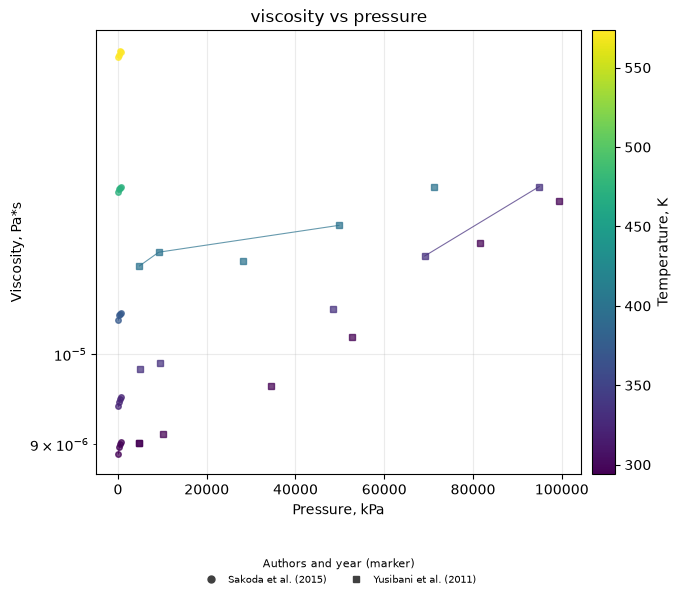

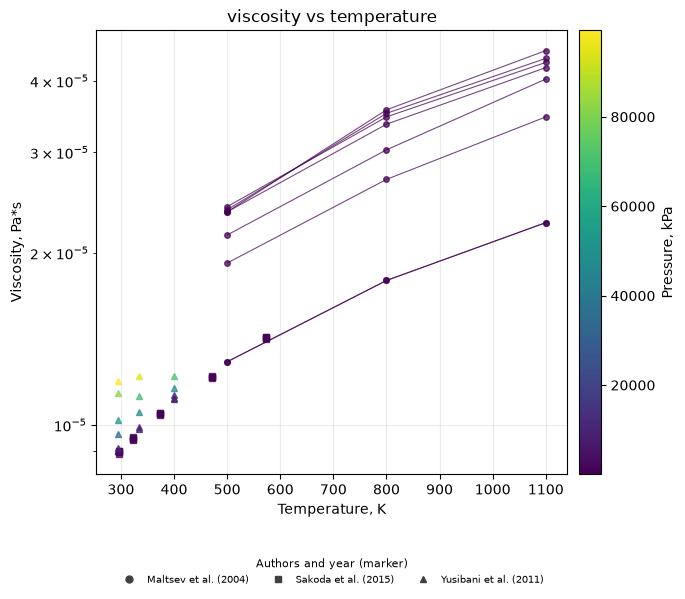

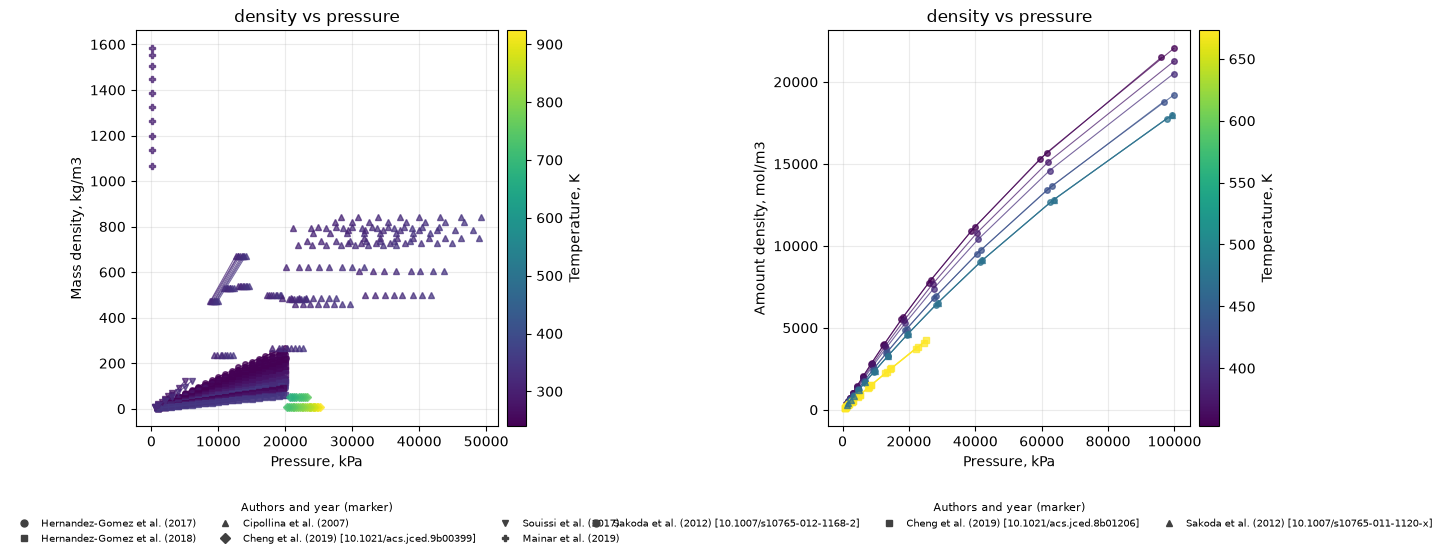

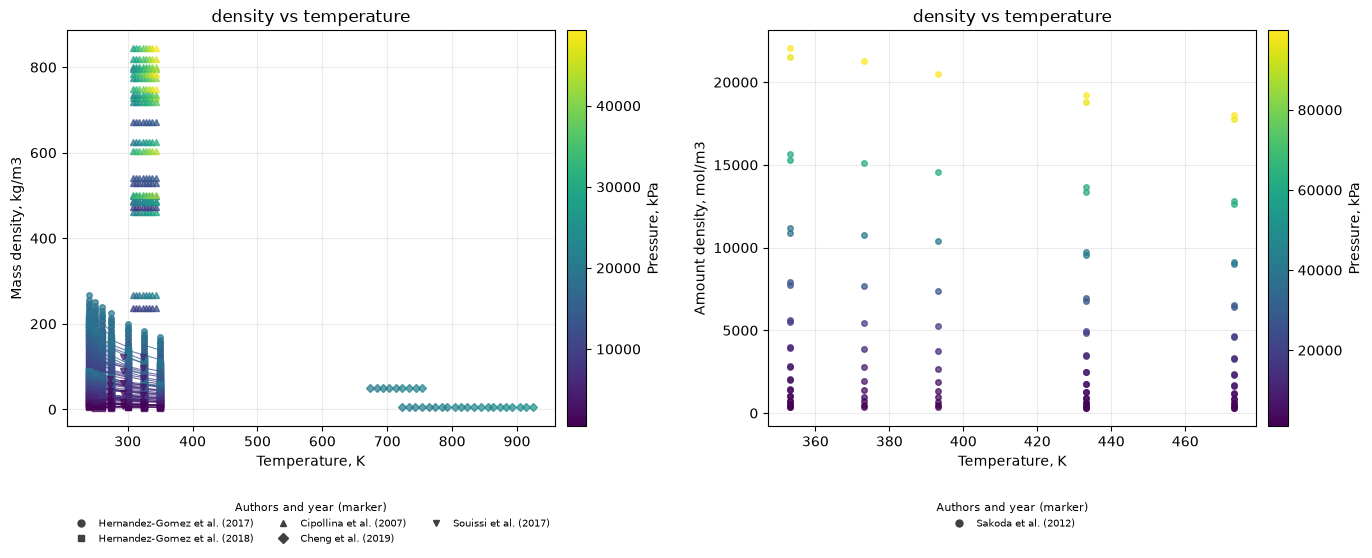

In [5]:
MARKERS = ("o", "s", "^", "D", "v", "P", "X", "<", ">", "*")


def primary_complementary_condition(
    raw_conditions: str, independent_name: str
) -> tuple[float | None, str]:
    target = "pressure" if "temperature" in independent_name.casefold() else "temperature"
    conditions = json.loads(raw_conditions)
    for condition in conditions:
        if target in str(condition["name"]).casefold():
            try:
                return float(condition["value"]), str(condition["name"])
            except (TypeError, ValueError):
                continue
    return None, f"Complementary {target}"


def plot_query(label: str, result) -> None:
    frame = result.table.to_pandas().copy()
    frame["x"] = pd.to_numeric(frame["independent_variable_value"])
    frame["y"] = pd.to_numeric(frame["value"])
    frame["publication_identity"] = frame["doi"].fillna(frame["source_sha256"])
    frame["publication"] = frame["citation_authors_year"]
    collisions = frame.groupby("publication")["publication_identity"].transform("nunique")
    frame.loc[collisions > 1, "publication"] += (
        " [" + frame.loc[collisions > 1, "publication_identity"] + "]"
    )
    complements = frame.apply(
        lambda row: primary_complementary_condition(
            row["complementary_conditions_json"],
            row["independent_variable_name"],
        ),
        axis=1,
        result_type="expand",
    )
    frame[["complementary_value", "complementary_label"]] = complements
    properties = tuple(frame["property_name"].drop_duplicates())
    figure, axes = plt.subplots(
        1,
        len(properties),
        figsize=(7 * len(properties), 6.0),
        squeeze=False,
    )
    largest_publication_count = 0
    for axis, property_name in zip(axes[0], properties, strict=True):
        selected = frame[frame["property_name"] == property_name]
        publications = tuple(selected["publication"].drop_duplicates())
        largest_publication_count = max(largest_publication_count, len(publications))
        marker_by_publication = {
            publication: MARKERS[index % len(MARKERS)]
            for index, publication in enumerate(publications)
        }
        numeric_conditions = pd.to_numeric(selected["complementary_value"], errors="coerce")
        finite_conditions = numeric_conditions.dropna()
        lower = float(finite_conditions.min()) if not finite_conditions.empty else 0.0
        upper = float(finite_conditions.max()) if not finite_conditions.empty else 1.0
        if lower == upper:
            lower -= 0.5
            upper += 0.5
        normalization = Normalize(vmin=lower, vmax=upper)
        colormap = plt.get_cmap("viridis")
        grouped = selected.groupby(
            [
                "publication",
                "complementary_value",
                "complementary_conditions_json",
            ],
            dropna=False,
            sort=False,
        )
        for (publication, condition_value, _signature), group in grouped:
            ordered = group.sort_values("x")
            color = (
                colormap(normalization(float(condition_value)))
                if pd.notna(condition_value)
                else "0.55"
            )
            axis.plot(
                ordered["x"],
                ordered["y"],
                color=color,
                marker=marker_by_publication[publication],
                linewidth=0.8 if len(ordered) > 1 else 0,
                markersize=4,
                alpha=0.72,
            )
        axis.set_xlabel(str(selected["independent_variable_name"].iloc[0]))
        axis.set_ylabel(str(property_name))
        if "viscosity" in str(property_name).casefold():
            axis.set_yscale("log")
        axis.set_title(label.replace("_", " "))
        axis.grid(alpha=0.25)
        publication_handles = [
            Line2D(
                [],
                [],
                color="0.25",
                marker=marker_by_publication[publication],
                linestyle="None",
                markersize=5,
                label=publication,
            )
            for publication in publications
        ]
        axis.legend(
            handles=publication_handles,
            title="Authors and year (marker)",
            loc="upper center",
            bbox_to_anchor=(0.5, -0.17),
            ncol=min(3, len(publications)),
            fontsize=7,
            title_fontsize=8,
            frameon=False,
        )
        colorbar = figure.colorbar(
            ScalarMappable(norm=normalization, cmap=colormap),
            ax=axis,
            pad=0.02,
        )
        colorbar.set_label(str(selected["complementary_label"].iloc[0]))
    figure.tight_layout()
    figure.subplots_adjust(bottom=0.28 if largest_publication_count > 3 else 0.20)
    plt.show()


for query_label, query_result in results.items():
    plot_query(query_label, query_result)

## One analysis-ready CSV per query

Each CSV has one row per property observation. Temperature, pressure,
composition, and the selected property are ordinary physical columns;
DOI, authors/year, system, method, and dataset identity follow them. The
compact `metadata` column retains uncertainties, citations, samples, devices,
and source provenance. Files are ignored by Git and excluded from packages.

In [6]:
csv_manifest = pd.DataFrame(
    [
        {
            "query": label,
            "CSV": str(
                result.write_csv(LOCAL_EXPORT / "h2" / f"{label}.csv").relative_to(PROJECT_ROOT)
            ),
            "rows": len(result.analysis_table.rows),
            "columns": len(result.analysis_table.columns),
        }
        for label, result in results.items()
    ]
)
display(csv_manifest)

,query,CSV,rows,columns
0,viscosity_vs_pressure,notebooks/local-only/exports/h2/viscosity_vs_p...,37,12
1,viscosity_vs_temperature,notebooks/local-only/exports/h2/viscosity_vs_t...,61,13
2,density_vs_pressure,notebooks/local-only/exports/h2/density_vs_pre...,1182,24
3,density_vs_temperature,notebooks/local-only/exports/h2/density_vs_tem...,1127,19


In [7]:
preview_label = next(label for label, result in results.items() if result.table.rows)
print(f"Analysis-ready columns for {preview_label!r}:")
display(results[preview_label].analysis_table.to_pandas().head())

Analysis-ready columns for 'viscosity_vs_pressure':


,"Temperature, K","Pressure, kPa","Viscosity, Pa*s",DOI,Authors/Year,System,System Type,Phases,Method,Data Category,Dataset,metadata
0,296.26,102.8,8.9e-06,10.1016/j.jct.2015.04.028,Sakoda et al. (2015),hydrogen,pure,Gas,Vibrating wire viscometry,transport,10.1016/j.jct.2015.04.028#pure-or-mixture-1,"{""conditions"":[{""component"":null,""definition_r..."
1,322.56,111,9.41e-06,10.1016/j.jct.2015.04.028,Sakoda et al. (2015),hydrogen,pure,Gas,Vibrating wire viscometry,transport,10.1016/j.jct.2015.04.028#pure-or-mixture-1,"{""conditions"":[{""component"":null,""definition_r..."
2,373.12,111.6,1.041e-05,10.1016/j.jct.2015.04.028,Sakoda et al. (2015),hydrogen,pure,Gas,Vibrating wire viscometry,transport,10.1016/j.jct.2015.04.028#pure-or-mixture-1,"{""conditions"":[{""component"":null,""definition_r..."
3,472.13,111.4,1.209e-05,10.1016/j.jct.2015.04.028,Sakoda et al. (2015),hydrogen,pure,Gas,Vibrating wire viscometry,transport,10.1016/j.jct.2015.04.028#pure-or-mixture-1,"{""conditions"":[{""component"":null,""definition_r..."
4,573.48,98.9,1.416e-05,10.1016/j.jct.2015.04.028,Sakoda et al. (2015),hydrogen,pure,Gas,Vibrating wire viscometry,transport,10.1016/j.jct.2015.04.028#pure-or-mixture-1,"{""conditions"":[{""component"":null,""definition_r..."


## Interpretation and limitations

- Fewer than ten publications are returned when fewer than ten qualify.
- Counts are reported property-variable pairs, not independent experiments.
- A property substring may select multiple exact ThermoML properties; plots
  keep them separate.
- Plot color parameterizes the complementary pressure or temperature; marker
  identifies the authors-year citation. DOI remains in the table, and resolves
  a label collision if two publications share the same authors-year string.
  Connecting segments require the complete complementary-condition signature
  to be identical.
- Fixed constraints are not treated as varied axes. They are exported as
  physical columns and retain their full descriptors in `metadata.conditions`.
- The pinned NIST snapshot contains publications through 2019. Its malformed
  XML members are recovered only from paired official JSON and are reported
  explicitly; neither passed the H₂ InChIKey prefilter here.
- ThermoML records preserve source representation but are not critically
  evaluated; scientific use should consult and cite the original articles.